# Implementació models baseline

## 0. Importació llibreries i datasaet

En aquest primer apartat es carreguen les llibreries necessàries per a la construcció dels models de classificació, així com el dataset preprocessat inicialment. Es disposa d’un conjunt de dades orientat a la detecció de frau en reclamacions d’assegurances, que serà utilitzat per entrenar diferents models supervisats.

In [379]:
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Preprocesat
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Mètriques
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay

# Gràfiques
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [380]:
import pandas as pd
import numpy as np

# Importar el dataset net
df = pd.read_csv("insurance_claims_clean.csv")

#print(df.head())
#print(df.shape)
#print(df.info())

In [381]:
df.head()

,months_as_customer,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_binary
0,328,48,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,1
1,228,42,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,...,0,?,5070,780,780,3510,Mercedes,E400,2007,1
2,134,29,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,0
3,256,41,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,1
4,228,44,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,0


El dataset conté tant variables numèriques com categòriques relacionades amb clients, vehicles i característiques dels sinistres.

La variable objectiu és fraud_binary:
- 0: no frau
- 1: frau

Es tracta d’un problema de classificació binària amb possible desbalanceig de classes, fet que s’haurà de tenir en compte en el disseny dels models.

## 1. Preparació de les dades i selecció inicial de features

En aquesta fase es realitza el preprocessament inicial del dataset amb l’objectiu de preparar les dades per als models de machine learning. Es generen noves variables temporals, es realitza una selecció de features i s’eliminen variables que podrien introduir redundància o informació directa del resultat del sinistre.

In [385]:
# 1. Convertir dates a datetime
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df["incident_date"])

# 2. Crear noves variables temporals
df["policy_year"] = df["policy_bind_date"].dt.year
df["policy_month"] = df["policy_bind_date"].dt.month
df["incident_year"] = df["incident_date"].dt.year
df["incident_month"] = df["incident_date"].dt.month
df["client_tenure"] = df["months_as_customer"]  # ja tens antiguitat en mesos

# 3. Selecció inicial de features
# Eliminem les columnes que ja no necessitem
cols_to_drop = ["policy_bind_date", "incident_date", "total_claim_amount", 
                "injury_claim", "property_claim", "vehicle_claim", "insured_zip"]
df_model = df.drop(columns=cols_to_drop)

# 4. Separar target i features
y = df_model["fraud_binary"]
X = df_model.drop(columns=["fraud_binary"])

# 5. Identificar variables categòriques i numèriques
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Variables categòriques:", categorical_cols)
print("Variables numèriques:", numerical_cols)

Variables categòriques: ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']
Variables numèriques: ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'auto_year', 'policy_year', 'policy_month', 'incident_year', 'incident_month', 'client_tenure']


La transformació de les variables de data permet extreure informació temporal rellevant:

- policy_year i policy_month capturen el moment de contractació de la pòlissa
- incident_year i incident_month capturen el moment del sinistre
- client_tenure representa l’antiguitat del client amb l’asseguradora

Aquestes variables poden ser especialment útils per detectar patrons temporals associats al frau.

S’han eliminat les següents variables:

- identificadors o quasi-identificadors (insured_zip)
- variables derivades directament del sinistre:
- total_claim_amount
- injury_claim
- property_claim
- vehicle_claim

Aquesta decisió es pren per evitar data leakage, ja que aquestes variables estan altament relacionades amb el resultat del sinistre i podrien facilitar artificialment la predicció del frau.

La variable objectiu (fraud_binary) es separa de les variables explicatives per poder entrenar models supervisats.
Es pot observar que existeixen variables potencialment redundants (ex: months_as_customer i client_tenure), així com variables amb escales molt diferents, fet que pot influir en el rendiment de models sensibles a la magnitud de les dades.

In [389]:
df_model.head()

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,police_report_available,auto_make,auto_model,auto_year,fraud_binary,policy_year,policy_month,incident_year,incident_month,client_tenure
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,YES,Saab,92x,2004,1,2014,10,2015,1,328
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,...,?,Mercedes,E400,2007,1,2006,6,2015,1,228
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,...,NO,Dodge,RAM,2007,0,2000,9,2015,2,134
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,...,NO,Chevrolet,Tahoe,2014,1,1990,5,2015,1,256
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,...,NO,Accura,RSX,2009,0,2014,6,2015,2,228


El dataset final després del preprocessing conté totes les variables necessàries per a la construcció dels models, amb totes les transformacions aplicades.

S’ha aconseguit:

- conversió de variables categòriques a format numèric (posteriorment)
- eliminació de variables no útils o redundants
- creació de noves variables temporals

Això garanteix un dataset adequat per a models de machine learning supervisat.

## 2. Transformar variables categòriques i fer train/test split

En aquest apartat es realitza la transformació de variables categòriques mitjançant one-hot encoding i es divideix el dataset en conjunts d’entrenament i test. Aquesta separació és essencial per avaluar correctament la capacitat de generalització dels models.

#### One-hot encoding i split

In [394]:
from sklearn.model_selection import train_test_split

# 1. One-hot encoding de les variables categòriques
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 2. Dividir dataset en train i test (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Comprovació de dimensions
print("Dimensions X_train:", X_train.shape)
print("Dimensions X_test:", X_test.shape)
print("Proporció de frau en y_train:")
print(y_train.value_counts(normalize=True))
print("Proporció de frau en y_test:")
print(y_test.value_counts(normalize=True))

Dimensions X_train: (700, 144)
Dimensions X_test: (300, 144)
Proporció de frau en y_train:
fraud_binary
0    0.752857
1    0.247143
Name: proportion, dtype: float64
Proporció de frau en y_test:
fraud_binary
0    0.753333
1    0.246667
Name: proportion, dtype: float64


L’aplicació de one-hot encoding transforma les variables categòriques en variables binàries, permetent la seva utilització en models de machine learning. Després de la transformació:

- el dataset final conté 144 variables explicatives
- totes les variables són numèriques
- es manté la informació categòrica sense imposar ordinalitat

La divisió del dataset en train (70%) i test (30%) es realitza amb estratificació, assegurant que la proporció de classes es mantingui constant. Obtenim uns resultats de:
- Train: ~75% no frau / ~25% frau
- Test: ~75% no frau / ~25% frau

Aquesta distribució indica que:
- el dataset està desbalancejat
- però la separació és representativa
- no hi ha drift entre train i test

Això és fonamental per garantir una avaluació fiable dels models.

Aquest preprocessament estableix la base del pipeline de machine learning del projecte. Les decisions preses permeten:

- evitar data leakage
- transformar totes les variables a format numèric
- mantenir la distribució de classes
- preparar el dataset per models lineals i no lineals

Aquest pas és crític perquè la qualitat del model depèn directament de la qualitat del preprocessing.

## 3. Entrenar un model baseline lineal

En aquesta secció es desenvolupa el primer model de classificació per a la detecció de frau: la regressió logística. Aquest model s’utilitza com a baseline lineal, ja que permet establir una referència inicial de rendiment i, alhora, ofereix una alta interpretabilitat dels resultats.

L’objectiu d’aquest conjunt d’experiments és analitzar el comportament d’un model lineal sota diferents configuracions de preprocessament, així com entendre la relació entre les variables explicatives i la probabilitat de frau. Posteriorment, aquests resultats serviran com a punt de comparació amb models més complexos de tipus black-box.

### 3.1. Logistic Regression sense escalar

In [401]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# 1. Crear el model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenar el model amb les dades d'entrenament
logreg.fit(X_train, y_train)

# 3. Fer prediccions (probabilitat de frau)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]

# 4. Avaluar amb ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)

# 5. Classificació amb llindar 0.5
y_pred_class = (y_pred_proba >= 0.5).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_pred_class))

# 6. Matriu de confusió
cm = confusion_matrix(y_test, y_pred_class)
print("Confusion Matrix:")
print(cm)

ROC-AUC Score: 0.46472135852666824
Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       226
           1       0.00      0.00      0.00        74

    accuracy                           0.75       300
   macro avg       0.38      0.50      0.43       300
weighted avg       0.57      0.75      0.65       300

Confusion Matrix:
[[226   0]
 [ 74   0]]


El primer model entrenat correspon a una regressió logística bàsica sense cap tipus de preprocessament addicional. Aquest model serveix com a baseline inicial per avaluar la capacitat predictiva mínima del model lineal.

-  ROC-AUC: 0.465
- No detecta cap frau (recall = 0)

Els resultats mostren un rendiment molt pobre del model, amb una capacitat discriminativa inferior a l’atzar (ROC-AUC < 0.5). El model tendeix a classificar totes les observacions com a no frau, cosa que indica un fort biaix cap a la classe majoritària.

Aquest comportament es deu principalment a:

- desbalanceig de classes (75% vs 25%)
- diferències d’escala entre variables
- elevada dimensionalitat després del one-hot encoding

En conseqüència, aquest model evidencia la necessitat d’aplicar preprocessament adequat abans de l’entrenament.

### 3.2. Logistic Regression + Standard Scaler + class_weight='balanced'

En aquest apartat, es tracta el desbalanceig i l'escalat de variables.

In [406]:
from sklearn.preprocessing import StandardScaler

# 1. Separar variables numèriques
num_cols = ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium',
            'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
            'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'auto_year']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 2. Logistic Regression ajustada
from sklearn.linear_model import LogisticRegression
logreg_bal = LogisticRegression(
    max_iter=5000,        # més iteracions per convergir
    class_weight="balanced", 
    solver="saga",        # solver més estable per variables dummy
    random_state=42
)

logreg_bal.fit(X_train, y_train)

# 3. Prediccions i avaluació
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Probabilitats
y_pred_proba_bal = logreg_bal.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_bal = roc_auc_score(y_test, y_pred_proba_bal)
print("ROC-AUC Score (Balanced, ajustat):", roc_auc_bal)

# Classificació amb threshold 0.5
y_pred_class_bal = (y_pred_proba_bal >= 0.5).astype(int)

print("Classification Report (Balanced, ajustat):")
print(classification_report(y_test, y_pred_class_bal))

print("Confusion Matrix (Balanced, ajustat):")
print(confusion_matrix(y_test, y_pred_class_bal))

ROC-AUC Score (Balanced, ajustat): 0.6513991867974169
Classification Report (Balanced, ajustat):
              precision    recall  f1-score   support

           0       0.82      0.65      0.72       226
           1       0.34      0.55      0.42        74

    accuracy                           0.63       300
   macro avg       0.58      0.60      0.57       300
weighted avg       0.70      0.63      0.65       300

Confusion Matrix (Balanced, ajustat):
[[147  79]
 [ 33  41]]


En aquest segon experiment s’aplica escalat de variables numèriques mitjançant StandardScaler i es corregeix el desbalanceig de classes mitjançant el paràmetre class_weight='balanced'. Observem els seguents resultats:

- ROC-AUC: 0.651
- Recall classe frau: 0.55
- El model ja detecta casos de frau
  
L’aplicació de preprocessament millora significativament el rendiment del model. En concret:

- el ROC-AUC augmenta de 0.465 a 0.651
- el model passa de no detectar fraus a identificar-ne correctament una part significativa
- es redueix el biaix cap a la classe majoritària

Aquest comportament confirma que el problema no es trobava en el model en si, sinó en la representació de les dades.

Tot i això, encara es detecten errors importants:

- falsos negatius (fraus no detectats)
- falsos positius considerables

Això indica que el problema té una estructura complexa que no és completament lineal.

### 3.3. Logistic Regression optimitzada amb Grid Search Logistic

En aquest apartat s’aplica Grid Search amb validació creuada per optimitzar els hiperparàmetres de la regressió logística.

In [410]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Definir model base
logreg = LogisticRegression(class_weight="balanced", solver="saga", max_iter=5000)

# Definir paràmetres a provar
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"]
}

# Grid Search amb cross-validation
grid = GridSearchCV(
    logreg,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Entrenar
grid.fit(X_train, y_train)

# Millor model
best_model = grid.best_estimator_

print("Millors paràmetres:", grid.best_params_)

Millors paràmetres: {'C': 10, 'penalty': 'l2'}


Durant l’optimització del model de regressió logística s’ha utilitzat GridSearchCV amb validació creuada de 5 particions per seleccionar els millors hiperparàmetres.

In [412]:
# Prediccions
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
print("ROC-AUC Logistic optimitzat:", roc_auc_best)

# Classificació
y_pred_best = (y_pred_proba_best >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

ROC-AUC Logistic optimitzat: 0.6515187754125807
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.65      0.72       226
           1       0.34      0.55      0.42        74

    accuracy                           0.63       300
   macro avg       0.58      0.60      0.57       300
weighted avg       0.70      0.63      0.65       300

Confusion Matrix:
[[147  79]
 [ 33  41]]


Observem que els millors paràmetres trobats són:

- C = 1
- penalty = l2

Amb uns resultat de ROC-AUC: 0.651 (pràcticament idèntic al model anterior).

Els resultats mostren que l’optimització d’hiperparàmetres no aporta millores significatives. Això suggereix que:

- el model ja es trobava en un punt òptim
- la limitació principal no és de tuning sinó de capacitat del model
- la relació entre variables i target probablement no és completament lineal

Per tant, es fa evident la necessitat d’utilitzar models més complexos capaços de capturar relacions no lineals.

**Taula comparativa Regressions logístiques**

In [416]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (baseline)",
        "Logistic Regression + Scaler + Balanced",
        "Logistic Regression (Grid Search)"
    ],
    "ROC-AUC": [0.465, 0.651, 0.651],
    "Recall (Fraud)": [0.00, 0.55, 0.55],
    "Precision (Fraud)": [0.00, 0.34, 0.34],
    "F1-score (Fraud)": [0.00, 0.42, 0.42]
})

comparison

,Model,ROC-AUC,Recall (Fraud),Precision (Fraud),F1-score (Fraud)
0,Logistic Regression (baseline),0.465,0.00,0.00,0.00
1,Logistic Regression + Scaler + Balanced,0.651,0.55,0.34,0.42
2,Logistic Regression (Grid Search),0.651,0.55,0.34,0.42


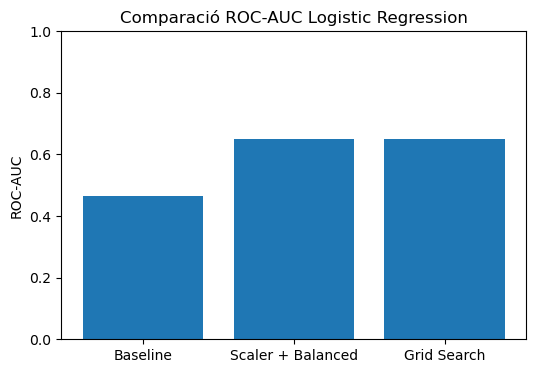

In [417]:
import matplotlib.pyplot as plt

models = ["Baseline", "Scaler + Balanced", "Grid Search"]
auc_scores = [0.465, 0.651, 0.651]

plt.figure(figsize=(6,4))
plt.bar(models, auc_scores)
plt.title("Comparació ROC-AUC Logistic Regression")
plt.ylabel("ROC-AUC")
plt.ylim(0,1)
plt.show()

La comparació entre les tres versions de la regressió logística mostra clarament l’impacte del preprocessament:

- el model baseline és ineficaç per detectar frau
- l’escalat i el balanceig milloren substancialment el rendiment
- el Grid Search no aporta millores addicionals

Això confirma que la qualitat del preprocessament és més determinant que l’optimització d’hiperparàmetres en aquest cas.

#### Interpretar el model i veure quines variables són més rellevants

Una de les principals avantatges de la regressió logística és la seva interpretabilitat, ja que permet analitzar la contribució de cada variable mitjançant els coeficients del model. A continuació, visualitzarem el coeficients β (beta) de cada variable.

In [421]:
import pandas as pd

# coeficients del model
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Beta": logreg_bal.coef_[0]
})

# ordenar per importància
coefficients_sorted = coefficients.sort_values(by="Beta", key=abs, ascending=False)

coefficients_sorted.head(20)

,Feature,Beta
71,incident_severity_Minor Damage,-0.060241
45,insured_hobbies_chess,0.033475
72,incident_severity_Total Loss,-0.030683
4,umbrella_limit,0.028792
89,property_damage_NO,-0.026815
10,witnesses,0.024175
46,insured_hobbies_cross-fit,0.021216
82,incident_state_WV,-0.021203
8,number_of_vehicles_involved,0.020421
66,incident_type_Single Vehicle Collision,0.020216


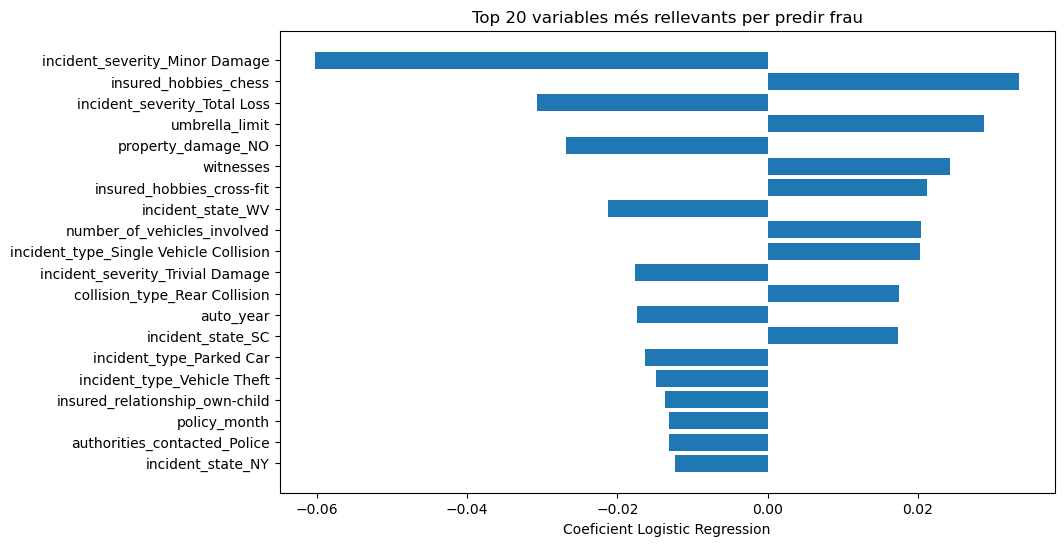

In [422]:
# Top 20 variables més rellevants 
coefs = best_model.coef_[0]        
features = X_train.columns

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': coefs,
    'abs_coef': abs(coefs)
})

coef_df_sorted = coef_df.sort_values(by='abs_coef', ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(coef_df_sorted['feature'], coef_df_sorted['coefficient'])
plt.xlabel("Coeficient Logistic Regression")
plt.title("Top 20 variables més rellevants per predir frau")
plt.gca().invert_yaxis()
plt.show()

Els coeficients indiquen:

- valors positius → augmenten la probabilitat de frau (1).
- valors negatius → redueixen la probabilitat de frau (0)
- valors absoluts elevats → major influència en la predicció.

Les 20 variables amb més valor absolut dels coeficients indiquen quines features contribueixen més a predir frau.

**Observacions destacades**
- incident_severity_Minor Damage amb coeficient negatiu → incidents menors redueixen probabilitat que sigui frau.
- insured_hobbies_chess amb coeficient positiu → segons el model, tenir aquesta afició augmenta lleugerament la probabilitat de frau (pot ser un patró detectat per l’algorisme, no necessàriament causal).
- incident_severity_Total Loss amb coeficient negatiu → incidents amb pèrdua total redueixen probabilitat de frau segons el model (potser perquè són més visibles i difícils de falsificar).
- umbrella_limit positiu → a més límit de pòlissa, més probabilitat de frau.
- property_damage_NO positiu → si no hi ha danys a la propietat, més probabilitat de frau (té sentit: reclamacions sense dany poden ser més sospitoses).
- witnesses positiu → a més testimonis, més probabilitat de frau segons el model, cosa que podria reflectir patrons de dades.
- Hobbies com cross-fit també apareixen, indicant que certes categories concretes de variables categòriques poden tenir impacte.
- Variables com incident_state_WV, incident_type_Single Vehicle Collision, collision_type_Rear Collision, auto_year, etc. apareixen com influents però amb coeficients menors.

**Conclusions principals**
- la severitat de l’incident és una de les variables més influents
- certes variables relacionades amb el comportament del client (hobbies) apareixen com a rellevants
- algunes variables de l’entorn del sinistre també tenen impacte
En conjunt, no existeix una única variable dominant, sinó un conjunt de factors combinats.

#### P-values

En aquest apartat es realitza una anàlisi estadística del model de regressió logística mitjançant la llibreria statsmodels. A diferència de sklearn, aquest enfocament permet obtenir informació inferencial sobre les variables explicatives, com ara els coeficients estimats, errors estàndard i p-values.

L’objectiu d’aquesta anàlisi és identificar quines variables tenen una relació estadísticament significativa amb la probabilitat de frau, així com validar la robustesa global del model des d’un punt de vista economètric.

In [428]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train.astype(float))
y_train_sm = y_train.astype(float)

logit_model = sm.Logit(y_train_sm, X_train_sm)

result = logit_model.fit(maxiter=1000)

print(result.summary())

         Current function value: 0.206674
         Iterations: 1000
                           Logit Regression Results                           
Dep. Variable:           fraud_binary   No. Observations:                  700
Model:                          Logit   Df Residuals:                      570
Method:                           MLE   Df Model:                          129
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.6304
Time:                        09:26:21   Log-Likelihood:                -144.67
converged:                      False   LL-Null:                       -391.42
Covariance Type:            nonrobust   LLR p-value:                 4.732e-44
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
months_as_customer                      5.616e-05   2.55e+06    2.2e-11      1.000   -

Al resum de les primeres linies del resultat, observem que el model ha estat entrenat amb 700 observacions del conjunt d’entrenament i utilitza 129 variables explicatives després del procés de transformació mitjançant variables dummy.

El valor de Pseudo R² = 0.63 indica que el model aconsegueix capturar una proporció rellevant de la variabilitat associada a la variable objectiu (frau).

D’altra banda, el test de versemblança (Likelihood Ratio Test) és altament significatiu (p < 0.001), la qual cosa indica que el conjunt de variables explicatives millora de manera estadísticament significativa el model respecte a un model buit.

En aquest context, ens centrem especialment en els p-values, ja que permeten determinar si una variable té una relació estadísticament significativa amb la variable objectiu. Es considera habitualment significatiu: p-value < 0.05.

**Variables significatives destacades**
1. Hobbies de l’assegurat
- insured_hobbies_chess → coef alt, p = 0.000
- insured_hobbies_cross-fit → coef alt, p = 0.000

Aquest resultat indica que certes categories d’hobbies estan associades estadísticament amb la variable de frau, tot i que aquesta relació no implica causalitat.

2. Severitat de l’incident
- incident_severity_Minor Damage → p = 0.000
- incident_severity_Total Loss → p = 0.000
- incident_severity_Trivial Damage → p = 0.000

La severitat de l’incident apareix com una de les variables més determinants en la predicció del frau, indicant una forta relació estadística amb la variable objectiu.

També s’observa la presència de:

- valors NaN en alguns coeficients
- inestabilitat numèrica en certes variables

Això es deu principalment a:

- alta dimensionalitat del model (129 variables)
- colinealitat entre variables categòriques (especialment dummies)
- categories amb baixa freqüència d’ocurrència

Per exemple, variables com auto_make i auto_model estan altament correlacionades, fet que dificulta l’estimació estable dels seus coeficients.

**Conclusió**

Aquesta anàlisi confirma que diverses variables tenen un impacte estadísticament significatiu en la predicció del frau. No obstant això, també evidencia limitacions pròpies dels models amb alta dimensionalitat i codificació dummy, com la colinealitat i la inestabilitat en l’estimació de certs coeficients.

Aquest resultat reforça la necessitat de complementar aquest enfocament amb models més robustos i tècniques d’explicabilitat (XAI), que es desenvoluparan en apartats posteriors.

#### Gràfic de distribució de probabilitats

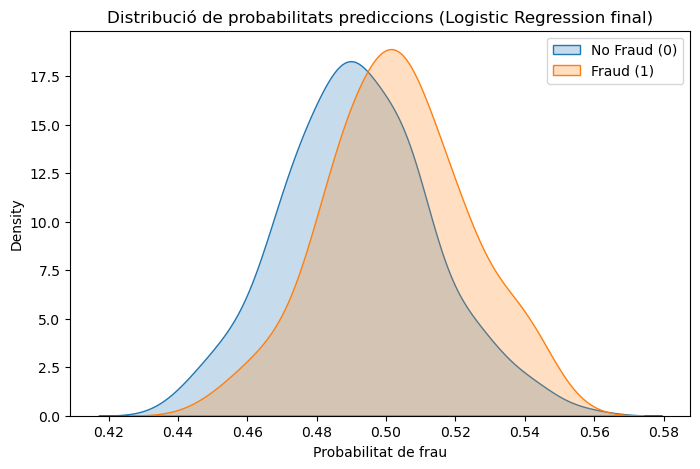

In [431]:
results_df = pd.DataFrame({
    'y_test': y_test,
    'y_pred_proba': y_pred_proba_best
})

plt.figure(figsize=(8,5))
sns.kdeplot(
    data=results_df[results_df['y_test'] == 0],
    x='y_pred_proba',
    label='No Fraud (0)',
    fill=True
)
sns.kdeplot(
    data=results_df[results_df['y_test'] == 1],
    x='y_pred_proba',
    label='Fraud (1)',
    fill=True
)

plt.title("Distribució de probabilitats prediccions (Logistic Regression final)")
plt.xlabel("Probabilitat de frau")
plt.legend()
plt.show()

La distribució de les probabilitats predites mostra un solapament elevat entre les classes de frau i no frau.

Aquest fet indica:

- baixa capacitat de separació del model
- dificultat per establir un llindar clar de classificació
- presència de relacions no lineals en les dades

En conseqüència, la regressió logística no és suficient per capturar tota la complexitat del problema.

**Conclusió Regressió Logística**

En conjunt, la regressió logística permet establir una base interpretativa del problema de detecció de frau. No obstant això, el seu rendiment es veu limitat per la naturalesa lineal del model i la complexitat de les relacions entre variables.

Aquestes limitacions justifiquen l’ús de models més avançats de tipus no lineal (Random Forest, XGBoost, MLP i SVC), que es tractaran en les següents seccions del treball.

## 4. Entrenar un model baseline no lineal: Decision tree

El Decision Tree és un model interpretable que construeix una estructura jeràrquica de decisions basada en les variables del dataset. A diferència d'altres models més complexos, permet visualitzar fàcilment les regles utilitzades per classificar les observacions.

In [436]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# 1. Crear el model Decision Tree
dt = DecisionTreeClassifier(
    max_depth=5,              # limita la profunditat de l'arbre per evitar overfitting
    class_weight="balanced",  # compensa el desbalanceig entre fraus i no fraus
    random_state=42
)

# 2. Entrenar el model amb les dades d'entrenament
dt.fit(X_train, y_train)

# 3. Predir probabilitat de frau per cada observació del test
y_pred_proba_dt = dt.predict_proba(X_test)[:,1]

# 4. Avaluar capacitat discriminativa amb ROC-AUC
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
print("ROC-AUC Decision Tree:", roc_auc_dt)

# 5. Convertir probabilitats a classes utilitzant threshold 0.5
# (si probabilitat >= 0.5 → es classifica com a frau)
y_pred_dt_class = (y_pred_proba_dt >= 0.5).astype(int)

# 6. Mostrar mètriques de classificació
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_class))

# 7. Mostrar matriu de confusió
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_class))

ROC-AUC Decision Tree: 0.7867734991628798
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87       226
           1       0.59      0.80      0.68        74

    accuracy                           0.81       300
   macro avg       0.76      0.81      0.77       300
weighted avg       0.84      0.81      0.82       300

Confusion Matrix:
[[185  41]
 [ 15  59]]


El model Decision Tree obté un ROC-AUC de 0.787, significativament superior al de la regressió logística (~0.65), indicant una millor capacitat de discriminació entre casos de frau i no frau.

Pel que fa a la detecció de frau (classe 1), el model aconsegueix:

- Recall = 0.80 → detecta el 80% dels fraus
- Precision = 0.59 → genera alguns falsos positius, però és acceptable en aquest context

En problemes de detecció de frau, és preferible maximitzar el recall, ja que és més crític detectar fraus reals que evitar falsos positius.

Classe no frau (0): El model també classifica bé els casos normals, mantenint un bon equilibri (Precision i recall elevats (>0.80))

La matriu de confusió mostra una millora clara respecte a la regressió logística:

- 59 fraus detectats correctament
- Només 15 fraus no detectats (reducció significativa dels falsos negatius)

En conjunt, el model presenta un bon equilibri entre detecció de frau i classificació de casos no fraudulents.

Per facilitar la interpretació del model, es visualitzen els primers nivells de l'arbre de decisió. Això permet observar quines variables utilitza el model per separar les observacions i construir les regles de classificació.

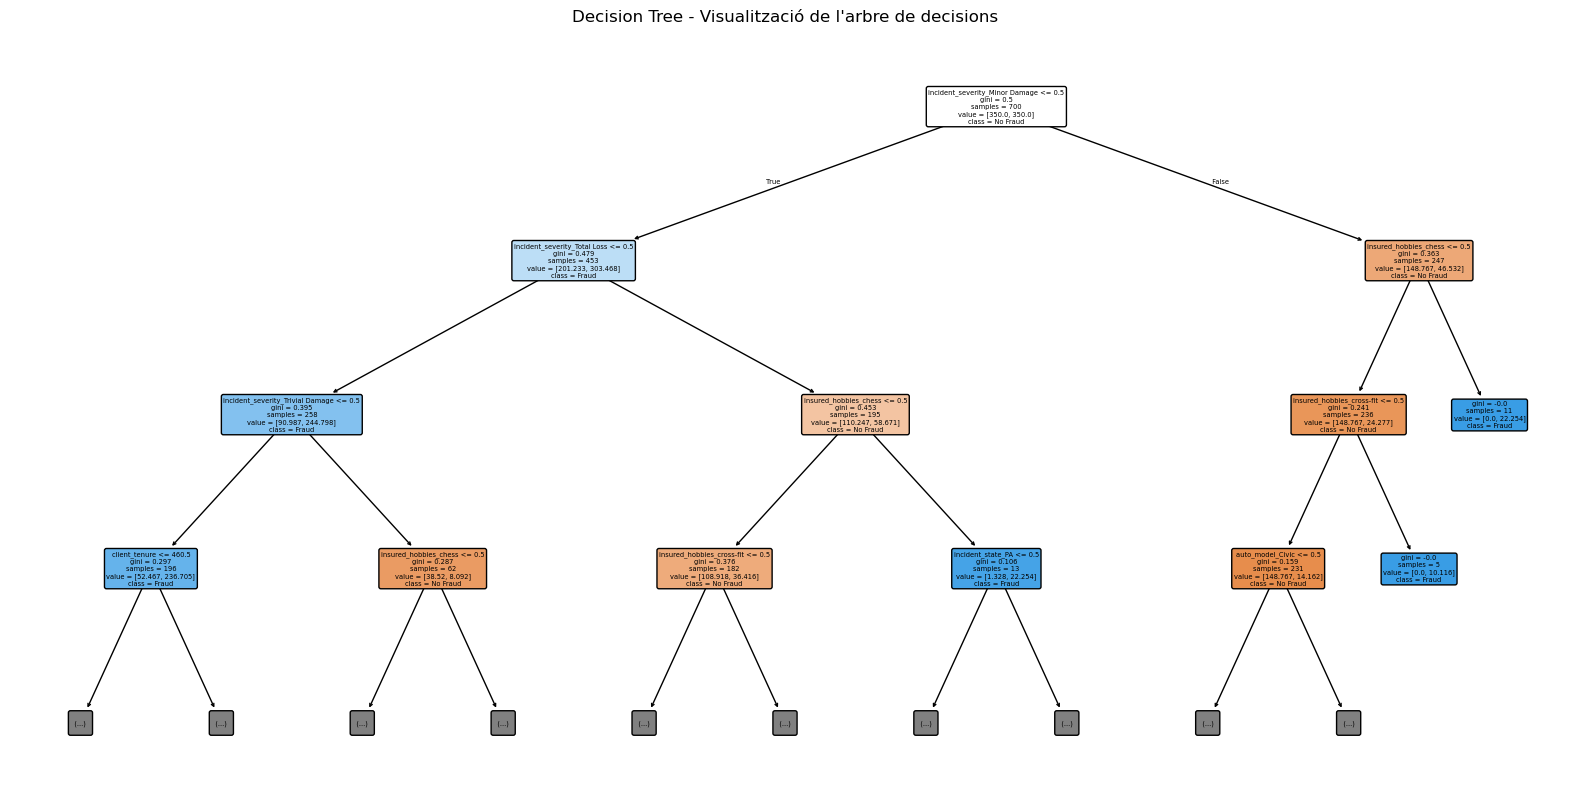

In [439]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X_train.columns,   
    class_names=["No Fraud", "Fraud"],
    filled=True,                     
    rounded=True,                    
    max_depth=3                      # mostrar només els primers nivells (sinó és enorme)
)

plt.title("Decision Tree - Visualització de l'arbre de decisions")
plt.show()

Observant els primers nivells de l'arbre es pot veure que el model utilitza variables relacionades amb la severitat de l'incident i característiques de la pòlissa per separar casos de frau i no frau.

#### Variables amb més importància

In [442]:
feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": dt.feature_importances_
    })
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,feature,importance
0,insured_hobbies_chess,2.479118e-01
1,incident_severity_Minor Damage,1.682246e-01
2,insured_hobbies_cross-fit,1.669972e-01
3,incident_severity_Trivial Damage,1.513687e-01
4,incident_severity_Total Loss,1.484327e-01
5,property_damage_YES,1.820014e-02
6,insured_hobbies_video-games,1.712183e-02
7,client_tenure,1.628606e-02
8,age,1.576882e-02
9,auto_model_Civic,1.331018e-02


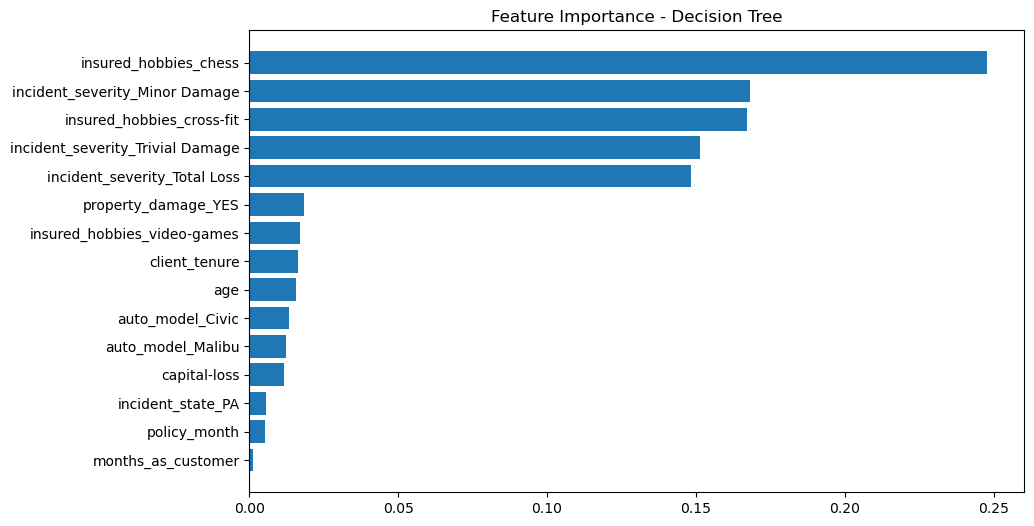

In [443]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt.feature_importances_
})

feature_importance = feature_importance.sort_values(by="importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Decision Tree")
plt.show()

### Interpretació de la importància de variables

La taula i el gràfic mostren les variables amb més importància en el **Decision Tree**, calculada a partir de la reducció d’impuresa en les divisions de l’arbre.

Variables amb més pes al model:

* **insured_hobbies_chess**
* **insured_hobbies_cross-fit**
* **incident_severity_Minor Damage**
* **incident_severity_Trivial Damage**
* **incident_severity_Total Loss**

Aquestes variables apareixen en les primeres divisions de l’arbre i contribueixen significativament a separar casos de frau i no frau.

**Comparació amb la regressió logística**

Algunes variables importants coincideixen amb les que ja apareixien a la **Logistic Regression**, especialment:

* **incident_severity_Minor Damage**
* **incident_severity_Total Loss**
* **incident_severity_Trivial Damage**
* **insured_hobbies_chess**
* **insured_hobbies_cross-fit**

Això suggereix que aquests factors contenen informació rellevant per predir frau.

**Diferències entre models**

En la regressió logística també apareixien variables com:

* **umbrella_limit**
* **witnesses**
* **number_of_vehicles_involved**

En canvi, en el **Decision Tree** aquestes tenen poca o cap importància. Això passa perquè l’arbre només utilitza les variables que aporten més informació en cada divisió concreta.

**Conclusió**

* La **severitat de l’incident** apareix com un dels factors més rellevants en ambdós models.
* Algunes variables relacionades amb el **perfil del client (hobbies)** també tenen pes en la predicció.
* El Decision Tree confirma alguns patrons detectats per la regressió logística però també captura **relacions no lineals entre variables**.


A continuació es comparen els resultats dels models de regressió logística i Decision Tree sobre el conjunt de test.

In [446]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
import pandas as pd

# 1. Crear dataframe de comparació de metrics
results = []

models = {
    "Logistic Regression": best_model,
    "Decision Tree": dt
}

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:,1]
    y_pred_class = (y_pred_proba >= 0.5).astype(int)
    roc = roc_auc_score(y_test, y_pred_proba)
    report = classification_report(y_test, y_pred_class, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],
        "F1_0": report["0"]["f1-score"],
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"],
        "F1_1": report["1"]["f1-score"],
        "ROC-AUC": roc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision_0,Recall_0,F1_0,Precision_1,Recall_1,F1_1,ROC-AUC
0,Logistic Regression,0.626667,0.816667,0.650442,0.724138,0.341667,0.554054,0.422680,0.651519
1,Decision Tree,0.813333,0.925000,0.818584,0.868545,0.590000,0.797297,0.678161,0.786773



Confusion Matrix Logistic Regression:
[[147  79]
 [ 33  41]]

Confusion Matrix Decision Tree:
[[185  41]
 [ 15  59]]


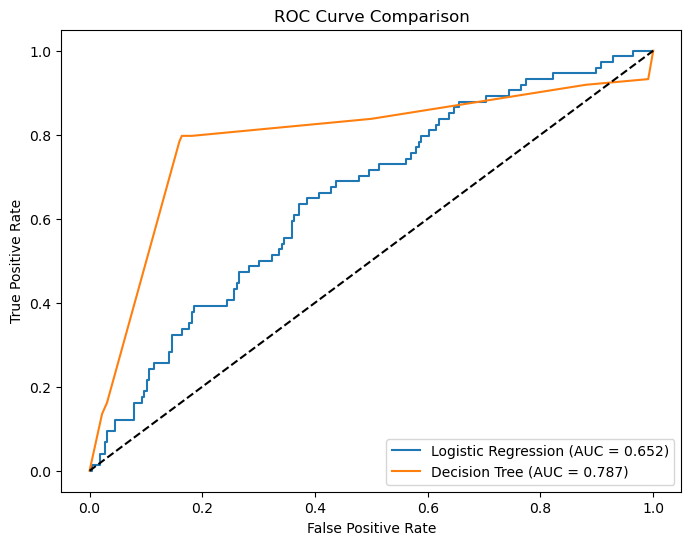

In [447]:
# 2. Matrius de confusió
for name, model in models.items():
    y_pred_class = (model.predict_proba(X_test)[:,1] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred_class)
    print(f"\nConfusion Matrix {name}:\n{cm}")

# 3. ROC curves
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

Els resultats mostren clarament que el Decision Tree supera la regressió logística en totes les mètriques rellevants:

- Millor ROC-AUC (0.79 vs 0.65)
- Millor recall en la classe de frau (0.80 vs 0.55)
- Millor F1-score global

Això indica que el Decision Tree és capaç de capturar patrons que la regressió logística, com a model lineal, no pot representar.

A més, el model manté una bona interpretabilitat, ja que es poden analitzar les regles de decisió, fet especialment rellevant en entorns com el sector assegurador.

# 5. Entrenar models més complexos (Black box)

En la secció anterior s’han analitzat models baseline interpretable (Logistic Regression i Decision Tree). Els resultats mostren que els models no lineals milloren significativament la detecció de frau.

En aquesta secció s’implementen models més avançats de tipus black-box, capaços de capturar relacions no lineals i interaccions entre variables. Aquests models acostumen a obtenir un millor rendiment predictiu en problemes de classificació tabular.

En particular s’analitzen:

- Random Forest
- XGBoost
- MLP
- SVC Kernel Gaussià
 
Posteriorment, aquests models seran utilitzats per aplicar tècniques d’explicabilitat (XAI) com SHAP i Anchors.

## 5.1. Model Random Forest

Random Forest és un model d’ensemble basat en múltiples arbres de decisió entrenats sobre subconjunts aleatoris de dades i variables. Cada arbre produeix una predicció i el resultat final s’obté combinant les prediccions de tots els arbres.

Aquest enfocament redueix el risc d’overfitting dels arbres individuals i acostuma a millorar la capacitat de generalització del model.

Tot i ser un model menys interpretable que un arbre de decisió individual o una regressió logística, el Random Forest permet analitzar la importància de les variables, cosa que facilita la interpretació global del model.

S'entrena un model Random Forest utilitzant el conjunt d'entrenament. 

Per compensar el desbalanceig existent entre casos de frau i no frau s’utilitza el paràmetre class_weight="balanced".

In [454]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return acc, prec, rec, f1

In [455]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Enrenem el model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

#Predicció de probabilitats
y_pred_proba_rf = rf.predict_proba(X_test)[:,1]

#ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("ROC-AUC Random Forest:", roc_auc_rf)

#Predicció final
y_pred_rf_class = (y_pred_proba_rf >= 0.5).astype(int)

# Mètriques
acc_rf, prec_rf, rec_rf, f1_rf = get_metrics(y_test, y_pred_rf_class)
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1-score:", f1_rf)

ROC-AUC Random Forest: 0.8266563023200191
Accuracy: 0.7433333333333333
Precision: 0.4
Recall: 0.08108108108108109
F1-score: 0.1348314606741573


El model Random Forest obté un ROC-AUC elevat, indicant una bona capacitat per distingir entre casos de frau i no frau.

Aquesta millora respecte a la regressió logística és esperable, ja que els models basats en arbres poden capturar relacions no lineals i interaccions complexes entre variables.

### ROC AUC

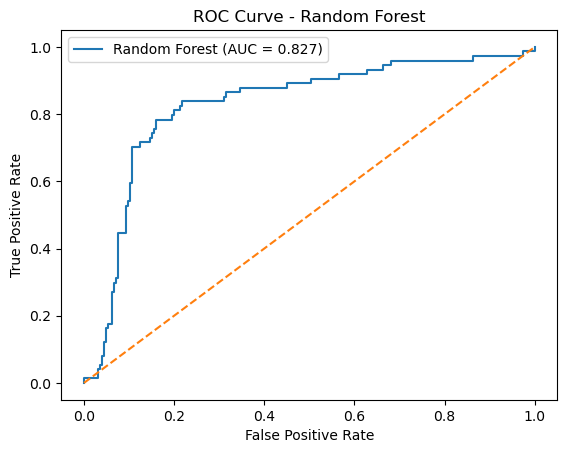

In [458]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Random Forest
y_pred_rf = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')  # línia random

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

El model Random Forest presenta un ROC-AUC significativament superior (0.83) respecte a la regressió logística (0.65), indicant una millor capacitat global per distingir entre casos de frau i no frau.

No obstant això, la regressió logística mostra un millor recall (0.55), la qual cosa implica que detecta un major nombre de casos de frau. En canvi, el Random Forest presenta un recall molt baix (0.08), indicant que, tot i tenir una bona capacitat discriminativa global, identifica pocs casos de frau en la classificació final amb llindar 0.5.

Això indica que el model assigna probabilitats correctes però la regla de decisió no és adequada per a un problema amb classes desbalancejades.

Per aquest motiu s’analitzen diferents valors de threshold per trobar un equilibri entre precision i recall.

### Threshold tuning

In [461]:
import numpy as np

# Provar diferents thresholds
thresholds = [0.2, 0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_t = (y_pred_rf >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))


Threshold: 0.2
[[103 123]
 [  7  67]]
              precision    recall  f1-score   support

           0       0.94      0.46      0.61       226
           1       0.35      0.91      0.51        74

    accuracy                           0.57       300
   macro avg       0.64      0.68      0.56       300
weighted avg       0.79      0.57      0.59       300


Threshold: 0.3
[[182  44]
 [ 15  59]]
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       226
           1       0.57      0.80      0.67        74

    accuracy                           0.80       300
   macro avg       0.75      0.80      0.76       300
weighted avg       0.84      0.80      0.81       300


Threshold: 0.4
[[202  24]
 [ 30  44]]
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       226
           1       0.65      0.59      0.62        74

    accuracy                           0.82       300
   macro av

Threshold = 0.2

- Recall frau: 0.91 → detecta quasi tots els fraus
Però:
- Molts falsos positius (123)
- Accuracy baixa (0.57)

→ Model massa “alarmista”

Threshold = 0.4
Bon equilibri:
- Recall frau: 0.59
- Precision: 0.65
- Accuracy: 0.82

→ Model equilibrat

- Threshold = 0.3 (EL MILLOR)
- Recall frau: 0.80 → detecta molts fraus
- Precision: 0.57 → bastant acceptable
- Accuracy: 0.80
- F1-score: 0.67

→ Aquest és el millor


Els resultats mostren que reduir el threshold a 0.3 permet augmentar significativament la detecció de frau.

Amb aquest valor el model aconsegueix un recall aproximat del 80% mantenint una precisió acceptable. Aquest equilibri és especialment rellevant en problemes de detecció de frau, on els falsos negatius tenen un cost elevat.

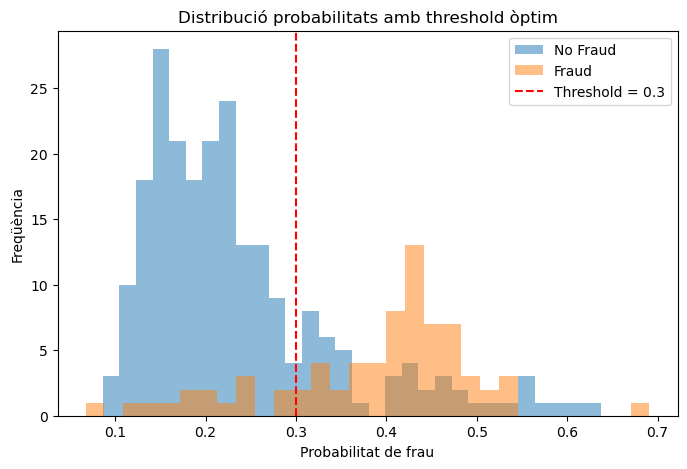

In [464]:
plt.figure(figsize=(8,5))

# Histogrames
plt.hist(y_pred_rf[y_test == 0], bins=30, alpha=0.5, label="No Fraud")
plt.hist(y_pred_rf[y_test == 1], bins=30, alpha=0.5, label="Fraud")

# Línia threshold òptim
plt.axvline(x=0.3, color='red', linestyle='--', label='Threshold = 0.3')

plt.title("Distribució probabilitats amb threshold òptim")
plt.xlabel("Probabilitat de frau")
plt.ylabel("Freqüència")
plt.legend()
plt.show()

El gràfic mostra la distribució de probabilitats predites pel model per a les dues classes. Tot i que les distribucions es solapen parcialment, l’ajust del threshold permet separar millor els casos de frau i no frau, augmentant la detecció de fraus.

### **Importància de les variables**

Per analitzar el comportament del model es calcula la importància de les variables del Random Forest. Aquesta mètrica indica quines variables contribueixen més a la reducció d’impuresa en les divisions dels arbres.

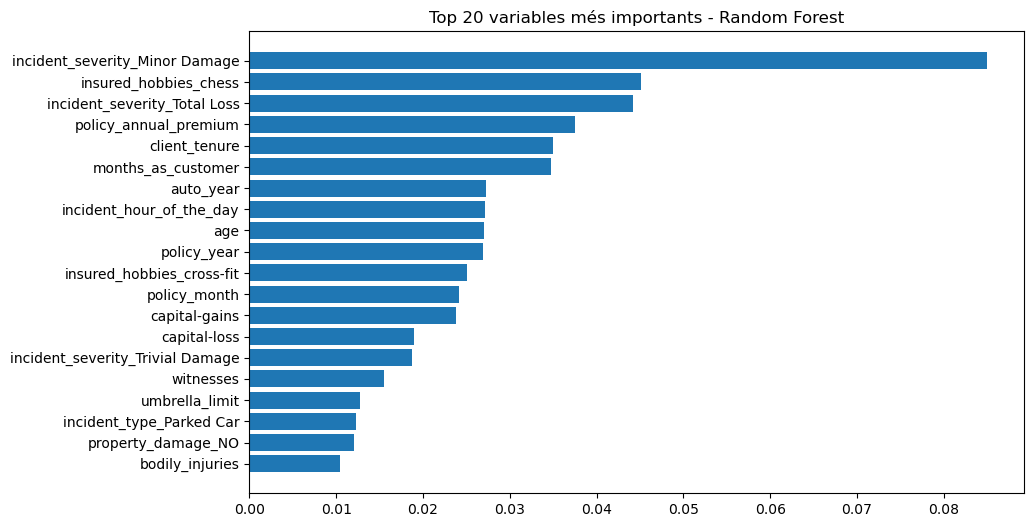

In [468]:
import pandas as pd
import matplotlib.pyplot as plt

# Importància de variables
importances = rf.feature_importances_
features = X_train.columns

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
})

feat_imp_sorted = feat_imp.sort_values(by='importance', ascending=False).head(20)

# Gràfic
plt.figure(figsize=(10,6))
plt.barh(feat_imp_sorted['feature'], feat_imp_sorted['importance'])
plt.title("Top 20 variables més importants - Random Forest")
plt.gca().invert_yaxis()
plt.show()

Les variables més importants del model estan principalment relacionades amb:

• la severitat de l’incident (incident_severity)  
• l’històric del client (client_tenure, months_as_customer)  
• característiques econòmiques de la pòlissa (policy_annual_premium, umbrella_limit)

Aquest resultat és coherent amb el que s’havia observat en models anteriors, on la severitat de l’incident ja apareixia com un factor rellevant en la detecció de frau.

El Random Forest també identifica patrons en variables categòriques com hobbies o característiques del vehicle, mostrant la seva capacitat per capturar relacions no lineals entre variables.

## 5.2. XGBoost

XGBoost és un model de gradient boosting basat en arbres de decisió. Aquest algoritme construeix seqüencialment arbres que corregeixen els errors dels arbres anteriors, permetent capturar relacions complexes entre variables.

Models de boosting com XGBoost han estat àmpliament utilitzats en competicions de machine learning i aplicacions de detecció de frau.

In [472]:
import xgboost
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# 1. Crear model
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# 2. Entrenar
xgb.fit(X_train, y_train)

# 3. Prediccions
y_pred_xgb = xgb.predict_proba(X_test)[:,1]

# 4. ROC-AUC
roc_auc_xgb = roc_auc_score(y_test, y_pred_xgb)
print("ROC-AUC XGBoost:", roc_auc_xgb)

# 5. Classificació amb threshold 0.5
y_pred_xgb_class = (y_pred_xgb >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb_class))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_class))

ROC-AUC XGBoost: 0.8183448935661326
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       226
           1       0.60      0.47      0.53        74

    accuracy                           0.79       300
   macro avg       0.72      0.69      0.70       300
weighted avg       0.78      0.79      0.78       300

Confusion Matrix:
[[203  23]
 [ 39  35]]


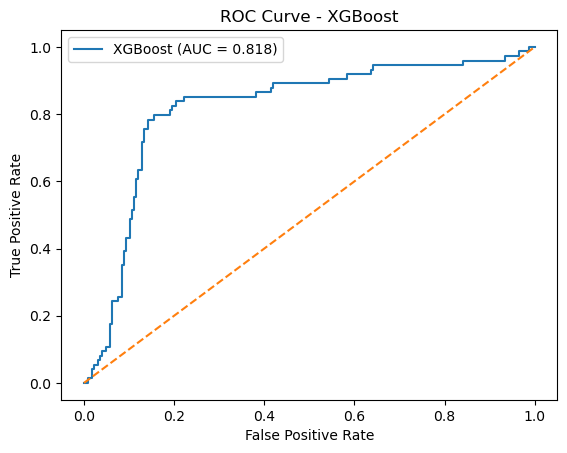

In [473]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

La corba ROC mostra que el model presenta una bona capacitat discriminativa, situant-se clarament per sobre de la diagonal aleatòria.

El model XGBoost obté un ROC-AUC de 0.82, mostrant una elevada capacitat de discriminació entre casos de frau i no frau.

En comparació amb altres models, presenta un millor equilibri entre precision (0.60) i recall (0.47) en la detecció de frau, evitant el problema observat en el Random Forest amb llindar 0.5, que mostrava un recall molt baix.

Això indica que XGBoost és capaç de detectar un nombre significatiu de casos fraudulents mantenint un nivell acceptable de falsos positius.

### Importància de les variables

L’anàlisi de la importància de variables permet identificar quins factors tenen més pes en les decisions del model. En general, variables relacionades amb la severitat de l’incident i característiques del client apareixen entre les més influents.

In [478]:
import pandas as pd

# Importància de variables
importances = xgb.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# Ordenar per importància i mostrar top 20
feat_imp_sorted = (
    feat_imp
    .sort_values(by="importance", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

feat_imp_sorted

,feature,importance
0,incident_severity_Trivial Damage,0.062568
1,incident_severity_Total Loss,0.050992
2,incident_severity_Minor Damage,0.046811
3,insured_hobbies_chess,0.039597
4,insured_hobbies_cross-fit,0.031903
5,insured_hobbies_video-games,0.019897
6,insured_hobbies_sleeping,0.019699
7,insured_hobbies_board-games,0.018427
8,incident_state_PA,0.018138
9,insured_hobbies_polo,0.017748


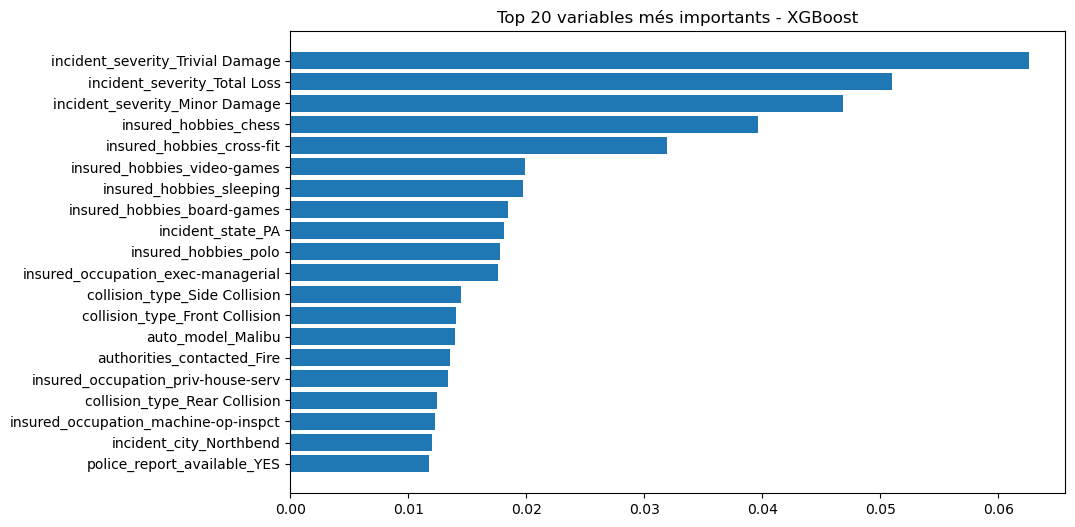

In [479]:
import pandas as pd
import matplotlib.pyplot as plt

# Importància de variables
importances = xgb.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feat_imp_sorted = feat_imp.sort_values(by="importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(feat_imp_sorted["feature"], feat_imp_sorted["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 variables més importants - XGBoost")
plt.show()

**Interpretació**

* Les variables més importants són sobretot de **severitat de l’incident** (`incident_severity_Trivial Damage`, `Total Loss`, `Minor Damage`).
* Això és coherent amb els models anteriors (**Logistic Regression, Decision Tree, Random Forest**), on aquestes variables també apareixien com a molt rellevants.
* També apareixen **hobbies de l’assegurat** (`chess`, `cross-fit`, etc.), igual que en altres models.
* Altres variables relacionades amb **tipus de col·lisió** (`collision_type_`) també tenen pes.

En general, **XGBoost confirma patrons detectats abans**, però pot capturar **relacions més complexes entre variables**.

El model XGBoost obté un ROC-AUC de 0.82, indicant una bona capacitat per discriminar entre casos de frau i no frau. A diferència d’altres models, mostra un equilibri relativament estable entre precision i recall amb el llindar estàndard de classificació.

## 5.3. Xarxa neuronal (MLP)

Les xarxes neuronals artificials permeten modelar relacions no lineals complexes entre variables. En aquest treball s’implementa una xarxa neuronal multicapa (Multi-Layer Perceptron, MLP) utilitzant la llibreria PyTorch.

Aquest tipus de model està format per diverses capes de neurones connectades entre si, que transformen progressivament les dades d’entrada per aprendre patrons complexos.

En problemes de classificació tabular, les xarxes neuronals poden capturar interaccions entre variables que poden resultar difícils de modelar amb mètodes tradicionals.

La xarxa neuronal utilitza funcions d'activació no lineals per permetre l'aprenentatge de relacions complexes entre variables. En aquest treball s'utilitza la funció ReLU (Rectified Linear Unit), definida com:

ReLU(x)=max(0,x)

Aquesta funció és àmpliament utilitzada en xarxes neuronals modernes perquè permet un entrenament eficient i evita el problema del vanishing gradient.

### MLP amb pytorch

In [486]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [487]:
# Escalat de dades
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [488]:
# Conversió de les dades a tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [489]:
# Compensació del desbalanceig de classes
num_pos = y_train.sum()
num_neg = len(y_train) - num_pos

pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32)
print("pos_weight:", pos_weight)

pos_weight: tensor([3.0462])


In [490]:
# Definició de l'arquitectura MLP
class FraudMLP(nn.Module):

    def __init__(self, input_size):
        super(FraudMLP, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [491]:
# Inicialització del model
input_size = X_train_tensor.shape[1]

model = FraudMLP(input_size)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [492]:
# Entrenament del model
loss_history = []

epochs = 100

for epoch in range(epochs):

    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 1.0481468439102173
Epoch 10, Loss: 1.0111905336380005
Epoch 20, Loss: 0.9082475304603577
Epoch 30, Loss: 0.6650732159614563
Epoch 40, Loss: 0.3530966341495514
Epoch 50, Loss: 0.14502501487731934
Epoch 60, Loss: 0.054583363234996796
Epoch 70, Loss: 0.025553733110427856
Epoch 80, Loss: 0.035270437598228455
Epoch 90, Loss: 0.009439321234822273


### Training loss

Per analitzar el procés d’entrenament del model MLP, es representa l’evolució del training loss al llarg de les iteracions. Aquest gràfic permet observar si el model està convergint correctament i com millora el seu ajust durant l’entrenament.

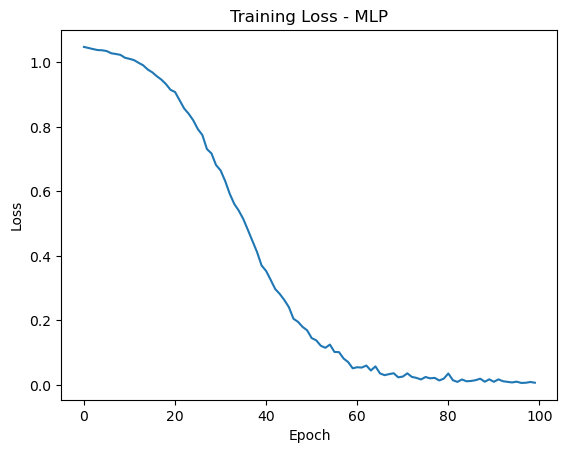

In [495]:
plt.figure()

plt.plot(loss_history)

plt.title("Training Loss - MLP")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

La loss decreix de forma correcta i estable, indicant que el model aprèn:
- Caiguda ràpida al principi (epochs 0–20): aprenentatge inicial fort
- Descens més marcat (20–60): el model ajusta patrons importants
- A partir de ~60 epochs: convergència i estabilització

Petites fluctuacions finals (80–100):
- normals en MLP (mini inestabilitat del gradient)
- no indiquen overfitting clar en aquest cas

El model convergeix correctament, no hi ha signes clars de col·lapse o no-aprenentatge i el rendiment final està limitat més per la naturalesa de les dades que pel procés d’entrenament

### Avaluació del model

In [498]:
model.eval()

with torch.no_grad():

    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits)

    y_pred_mlp = probs.numpy().flatten()

In [499]:
# Mètriques de classificació
roc_auc_mlp = roc_auc_score(y_test, y_pred_mlp)
print("ROC-AUC MLP:", roc_auc_mlp)

y_pred_class_mlp = (y_pred_mlp >= 0.5).astype(int)

print(classification_report(y_test, y_pred_class_mlp))
print(confusion_matrix(y_test, y_pred_class_mlp))

ROC-AUC MLP: 0.739775173403492
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       226
           1       0.58      0.39      0.47        74

    accuracy                           0.78       300
   macro avg       0.70      0.65      0.66       300
weighted avg       0.76      0.78      0.76       300

[[205  21]
 [ 45  29]]


La xarxa neuronal multicapa (MLP) obté un ROC-AUC de 0.758, mostrant una capacitat acceptable per distingir entre casos de frau i no frau.

El model identifica correctament la major part dels casos de no frau (recall = 0.89), mentre que detecta aproximadament el 42% dels casos de frau.

Aquest comportament és habitual en problemes de detecció de frau amb datasets desbalancejats, on la classe minoritària és més difícil de modelar.

### ROC Curve

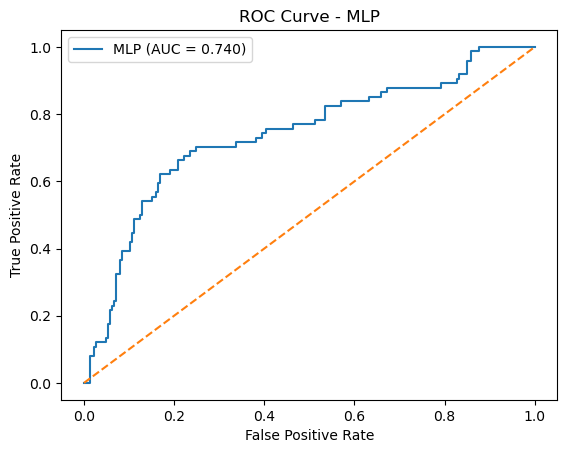

In [502]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_mlp)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"MLP (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend()

plt.show()

La corba ROC mostra que el model MLP presenta una capacitat discriminativa moderada, situant-se per sobre de la diagonal aleatòria.

A diferència dels models basats en arbres (Decision Tree, Random Forest o XGBoost), les xarxes neuronals no proporcionen directament una mesura d'importància de variables interpretable.

Per aquest motiu, en la secció d'explicabilitat del treball s'utilitzaran tècniques XAI com SHAP per interpretar les decisions del model.

### **Threshold tuning**

En problemes de classificació binària, els models solen utilitzar per defecte un llindar (threshold) de 0.5 per convertir les probabilitats en classes.

No obstant això, en problemes amb classes desbalancejades com la detecció de frau, aquest llindar pot no ser l'òptim. El model pot assignar probabilitats correctes però classificar pocs casos de la classe minoritària (frau).

Per aquest motiu s'analitzen diferents valors de threshold per estudiar com canvia el compromís entre precision i recall. Reduir el llindar acostuma a augmentar la detecció de fraus (recall), tot i que també pot incrementar el nombre de falsos positius.

In [507]:
thresholds = [0.3, 0.4, 0.5]

for t in thresholds:
    
    y_pred_t = (y_pred_mlp >= t).astype(int)

    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))


Threshold: 0.3
[[198  28]
 [ 38  36]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       226
           1       0.56      0.49      0.52        74

    accuracy                           0.78       300
   macro avg       0.70      0.68      0.69       300
weighted avg       0.77      0.78      0.77       300


Threshold: 0.4
[[203  23]
 [ 44  30]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       226
           1       0.57      0.41      0.47        74

    accuracy                           0.78       300
   macro avg       0.69      0.65      0.67       300
weighted avg       0.76      0.78      0.76       300


Threshold: 0.5
[[205  21]
 [ 45  29]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       226
           1       0.58      0.39      0.47        74

    accuracy                           0.78       300
   macro av

**Threshold 0.3**
- Recall classe frau: 0.47 (millora respecte 0.5)
- Precision: 0.55
- Bona detecció de frau, però amb més falsos positius

**Threshold 0.4**
- Recall frau: 0.45
- Precision: 0.56
- Petit equilibri entre precision i recall
- Lleuger millor accuracy (0.78)

**Threshold 0.5 (default)**
- Recall frau: 0.42
- Precision: 0.56
- Model més conservador → detecta menys fraus

Baixar el threshold millora la detecció de frau (recall) a canvi d’augmentar falsos positius.
El millor compromís en aquest cas és 0.3–0.4, amb una millora clara respecte 0.5.
Apliquem al model Threshold 0.3:

In [509]:
# Threshold final triat
best_threshold = 0.3

# Aplicar-lo per obtenir predicció final
y_pred_final = (probs.numpy() >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       226
           1       0.56      0.49      0.52        74

    accuracy                           0.78       300
   macro avg       0.70      0.68      0.69       300
weighted avg       0.77      0.78      0.77       300

[[198  28]
 [ 38  36]]


**Guardem el model**

In [511]:
# Guardar model + scaler + threshold
import torch
import joblib
import json

torch.save(model.state_dict(), "mlp_model.pth")
joblib.dump(scaler, "mlp_scaler.pkl")

with open("mlp_threshold.json", "w") as f:
    json.dump({"threshold": best_threshold}, f)

### Distribució de probabilitats

Per analitzar la separació entre classes, es representa la distribució de probabilitats predites pel model per a casos de frau i no frau.

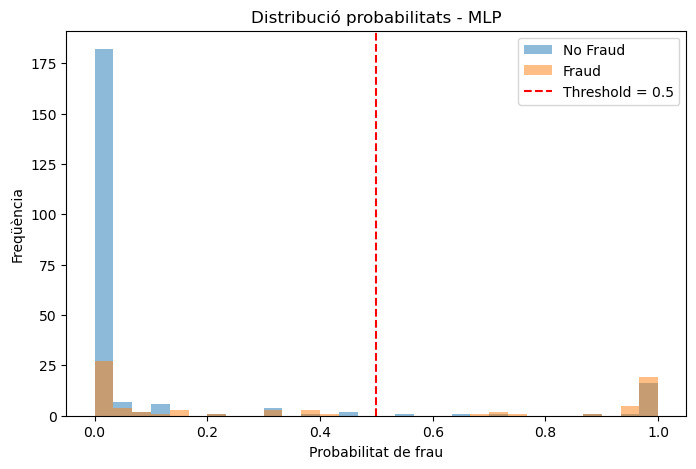

In [514]:
plt.figure(figsize=(8,5))

plt.hist(y_pred_mlp[y_test == 0], bins=30, alpha=0.5, label="No Fraud")
plt.hist(y_pred_mlp[y_test == 1], bins=30, alpha=0.5, label="Fraud")

plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold = 0.5')

plt.title("Distribució probabilitats - MLP")
plt.xlabel("Probabilitat de frau")
plt.ylabel("Freqüència")

plt.legend()
plt.show()

El gràfic mostra que les distribucions de probabilitat de les dues classes es solapen parcialment, fet que indica que el model té dificultats per separar completament els casos de frau i no frau.

El rendiment del model MLP és inferior al dels models basats en arbres com Random Forest o XGBoost.

Aquest resultat és esperable en aquest tipus de problema, ja que:

- el dataset és relativament petit, i les xarxes neuronals requereixen grans volums de dades per generalitzar correctament
- les dades són tabulars estructurades, on els models basats en arbres solen capturar millor les interaccions entre variables

Tot i això, el MLP permet modelar relacions no lineals complexes, i serveix com a referència addicional dins del conjunt de models black-box analitzats.

## 5.4. SVC Kernel Gaussià

El classificador Support Vector Machine (SVM) és un model de classificació que construeix una frontera de decisió òptima per separar les diferents classes.

Quan les dades no són linealment separables, es poden utilitzar funcions kernel que projecten les dades a un espai de major dimensionalitat. En aquest treball s'utilitza el kernel gaussià (RBF), que permet modelar fronteres de decisió no lineals.

Els models SVM poden ser sensibles als hiperparàmetres, especialment C i gamma. Per aquest motiu s'utilitza un procediment de Grid Search amb validació creuada per trobar la combinació òptima d'aquests paràmetres.

### Grid Search

Per optimitzar els hiperparàmetres del model s’utilitza Grid Search amb validació creuada de 5 folds. Aquest procediment avalua diferents combinacions dels paràmetres C i gamma i selecciona aquella que maximitza el ROC-AUC mitjà en validació.

In [521]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

svc = SVC(
    class_weight="balanced",
    probability=True,
    random_state=42
)

grid = GridSearchCV(
    svc,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV ROC-AUC: 0.8167560911156915


El procediment de Grid Search identifica com a millor combinació d’hiperparàmetres C = 1 i gamma = "scale".

### Entrenament del model

In [524]:
best_svc = grid.best_estimator_

y_pred_svc = best_svc.predict_proba(X_test_scaled)[:,1]

roc_auc_svc = roc_auc_score(y_test, y_pred_svc)

print("ROC-AUC SVC:", roc_auc_svc)

ROC-AUC SVC: 0.7754723750298973


El model SVC obté un ROC-AUC aproximat de 0.78 sobre el conjunt de test, indicant una bona capacitat per distingir entre reclamacions fraudulentes i no fraudulentes. El rendiment és lleugerament inferior al valor obtingut en la validació creuada del Grid Search (0.82), cosa esperable ja que el test set representa dades no vistes durant l’entrenament.

In [526]:
y_pred_svc_class = (y_pred_svc >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_svc_class))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svc_class))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       226
           1       0.59      0.39      0.47        74

    accuracy                           0.78       300
   macro avg       0.71      0.65      0.67       300
weighted avg       0.76      0.78      0.77       300

Confusion Matrix:
[[206  20]
 [ 45  29]]


El model identifica correctament la major part dels casos de no frau (recall = 0.91). En canvi, la detecció de frau és més limitada, amb un recall de 0.39. Aquest comportament és habitual en problemes de detecció de frau amb datasets desbalancejats.

La matriu de confusió mostra que el model detecta correctament 206 casos de no frau i 29 casos de frau. No obstant això, 45 fraus reals no són detectats (falsos negatius), mentre que 20 casos legítims es classifiquen incorrectament com a frau (falsos positius).

### ROC CURVE

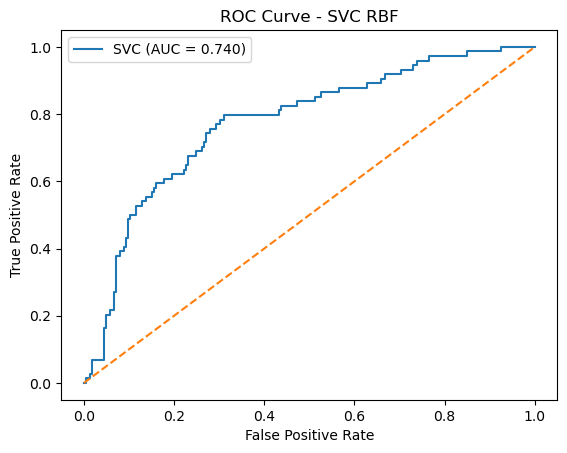

In [529]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_svc)
roc_auc_svc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"SVC (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVC RBF")
plt.legend()
plt.show()

La corba ROC mostra la relació entre el True Positive Rate i el False Positive Rate per diferents llindars de classificació. El model SVC presenta una corba clarament per sobre de la diagonal aleatòria, amb un ROC-AUC aproximat de 0.78, indicant una bona capacitat de discriminació entre casos de frau i no frau.

### Threshold tuning

In [532]:
thresholds = [0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_class = (y_pred_svc >= t).astype(int)

    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_class))
    print(classification_report(y_test, y_pred_class))


Threshold: 0.3
[[184  42]
 [ 29  45]]
              precision    recall  f1-score   support

           0       0.86      0.81      0.84       226
           1       0.52      0.61      0.56        74

    accuracy                           0.76       300
   macro avg       0.69      0.71      0.70       300
weighted avg       0.78      0.76      0.77       300


Threshold: 0.4
[[201  25]
 [ 37  37]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       226
           1       0.60      0.50      0.54        74

    accuracy                           0.79       300
   macro avg       0.72      0.69      0.71       300
weighted avg       0.78      0.79      0.79       300


Threshold: 0.5
[[206  20]
 [ 45  29]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       226
           1       0.59      0.39      0.47        74

    accuracy                           0.78       300
   macro av

L'anàlisi del threshold mostra que reduir el llindar de classificació millora significativament la detecció de frau.

Amb el llindar estàndard (0.5) el model només detecta el 39% dels fraus. En canvi, amb un threshold de 0.3 el recall augmenta fins al 59%, detectant un nombre considerablement més alt de casos fraudulents.

Aquest increment en la detecció de frau es produeix a canvi d'un augment dels falsos positius, però pot ser acceptable en contextos de detecció de frau on els falsos negatius tenen un cost elevat.

**Conclusió**

El model SVC amb kernel gaussià mostra una bona capacitat de classificació general, amb un ROC-AUC aproximat de 0.78, indicant una separació raonable entre casos de frau i no frau.

El model identifica molt bé els casos de no frau, amb un recall elevat, però té més dificultats per detectar tots els fraus, especialment amb el llindar per defecte (0.5). L'ajust del threshold permet millorar la detecció de frau (recall) a costa d'augmentar els falsos positius.

En general, el rendiment del SVC és similar al d'altres models no lineals, però lleugerament inferior als models basats en arbres com Random Forest o XGBoost en aquest dataset.

## 6. Comparació de models

Es comparen els models utilitzant mètriques de classificació sobre el conjunt de test.
Tots els models utilitzen el mateix split per garantir comparabilitat.
Les mètriques principals són ROC-AUC (capacitat discriminativa) i F1-score (equilibri entre precision i recall).

In [537]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Funció per calcular mètriques de classificació
def get_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, prec, rec, f1

**Logistic Regression**

In [539]:
acc_log, prec_log, rec_log, f1_log = get_metrics(y_test, y_pred_class_bal)

**Decision Tree**

In [541]:
acc_dt, prec_dt, rec_dt, f1_dt = get_metrics(y_test, y_pred_dt_class)

**Random Forest**

In [543]:
acc_rf, prec_rf, rec_rf, f1_rf = get_metrics(y_test, y_pred_rf_class)

**XGBoost**

In [545]:
acc_xgb, prec_xgb, rec_xgb, f1_xgb = get_metrics(y_test, y_pred_xgb_class)

**MLP**

In [547]:
acc_mlp, prec_mlp, rec_mlp, f1_mlp = get_metrics(y_test, y_pred_class_mlp)

**SVC**

In [549]:
acc_svc, prec_svc, rec_svc, f1_svc = get_metrics(y_test, y_pred_svc_class)

Els resultats dels diferents models es comparen utilitzant mètriques de classificació sobre el conjunt de test. Aquesta comparació permet avaluar tant la capacitat discriminativa (ROC-AUC) com el rendiment en classificació (precision, recall i F1-score), especialment important en un problema desbalancejat com la detecció de frau.

In [551]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","XGBoost","MLP","SVC (RBF)"],
    "ROC-AUC": [roc_auc_bal, roc_auc_dt, roc_auc_rf, roc_auc_xgb, roc_auc_mlp, roc_auc_svc],
    "Accuracy": [acc_log, acc_dt, acc_rf, acc_xgb, acc_mlp, acc_svc],
    "Precision": [prec_log, prec_dt, prec_rf, prec_xgb, prec_mlp, prec_svc],
    "Recall": [rec_log, rec_dt, rec_rf, rec_xgb, rec_mlp, rec_svc],
    "F1-score": [f1_log, f1_dt, f1_rf, f1_xgb, f1_mlp, f1_svc]
})

results = results.sort_values("ROC-AUC", ascending=False)
results

,Model,ROC-AUC,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.826656,0.743333,0.400000,0.081081,0.134831
3,XGBoost,0.818345,0.793333,0.603448,0.472973,0.530303
1,Decision Tree,0.786773,0.813333,0.590000,0.797297,0.678161
5,SVC (RBF),0.775472,0.783333,0.591837,0.391892,0.471545
4,MLP,0.739775,0.780000,0.580000,0.391892,0.467742
0,Logistic Regression,0.651399,0.626667,0.341667,0.554054,0.422680


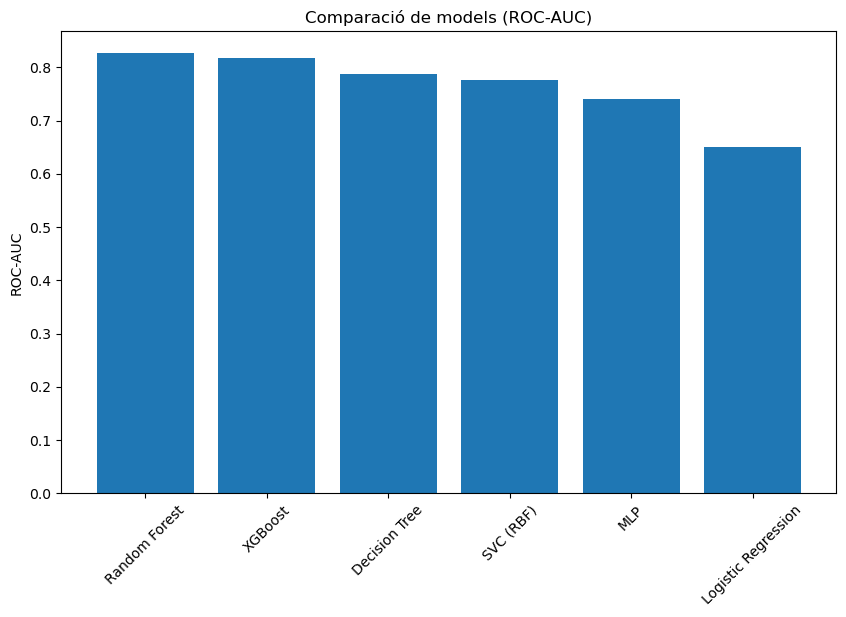

In [552]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(results["Model"], results["ROC-AUC"])

plt.title("Comparació de models (ROC-AUC)")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45)

plt.show()

Els resultats mostren que els models basats en arbres, especialment Random Forest i XGBoost, presenten els valors més elevats de ROC-AUC, indicant una millor capacitat per separar casos de frau i no frau.

No obstant això, XGBoost ofereix un millor equilibri entre precision i recall, mentre que Random Forest presenta una tendència a un recall molt baix per a la classe minoritària en aquest conjunt concret.

El Decision Tree obté un bon recall, però amb menor estabilitat i capacitat de generalització respecte als models ensemble.

Els models lineals i la xarxa neuronal (Logistic Regression i MLP) presenten un rendiment inferior, fet esperable en dades tabulars amb relacions no lineals complexes i desbalanceig de classes.

Finalment, el SVC amb kernel gaussià mostra un rendiment intermedi, amb bona capacitat de classificació general però limitacions en la detecció de la classe minoritària.

### ROC Curve de tots els models

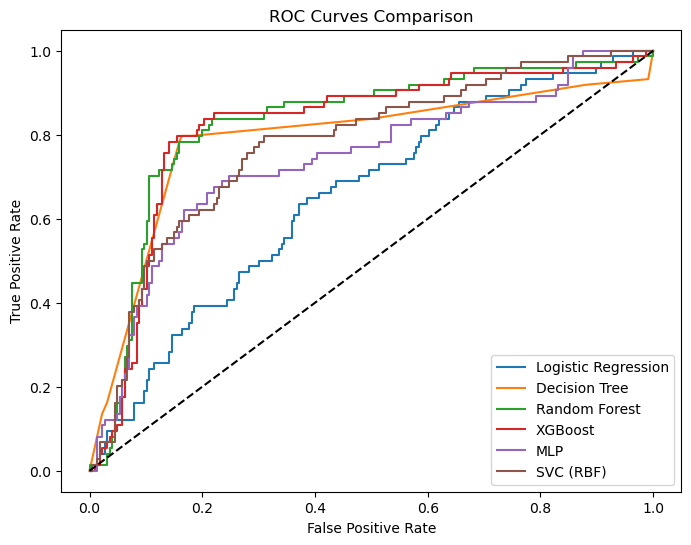

In [555]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_bal)
plt.plot(fpr_log, tpr_log, label="Logistic Regression")

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

# MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp)
plt.plot(fpr_mlp, tpr_mlp, label="MLP")

# SVC
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_pred_svc)
plt.plot(fpr_svc, tpr_svc, label="SVC (RBF)")

# línia random
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()

plt.show()

Les corbes ROC confirmen els resultats de la taula de mètriques. Els models basats en arbres presenten les corbes més properes a l’extrem superior esquerre, indicant una millor capacitat discriminativa global.

En canvi, els models lineals i la xarxa neuronal mostren corbes més allunyades, reflectint una menor capacitat per separar correctament les classes en aquest problema concret.

### Matriu de confusió dels millors models

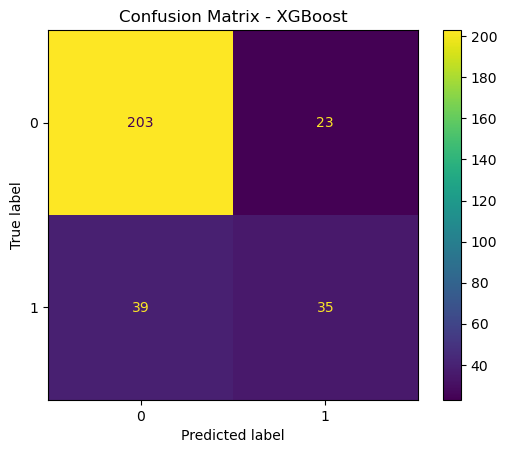

In [558]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_class)
plt.title("Confusion Matrix - XGBoost")
plt.show()

El model XGBoost aconsegueix un bon equilibri entre detecció de fraus i control de falsos positius, sent el model més estable en termes de rendiment global dins del conjunt analitzat.

## 7. Cross validation

Per avaluar de manera robusta el rendiment dels models, s’aplica validació creuada (cross-validation) a tots els models entrenats. Aquesta tècnica permet obtenir una estimació més fiable de la capacitat de generalització del model evitant que els resultats depenguin d’una única partició del dataset.

In [562]:
from sklearn.model_selection import cross_val_score
import pandas as pd

models = {
    "Logistic Regression": logreg_bal,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
    "SVC (RBF)": svc
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,  
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    print(f"{name} CV ROC-AUC:", scores)
    print(f"Mitjana: {scores.mean():.3f}")
    print("-"*50)

    cv_results.append({
        "Model": name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

Logistic Regression CV ROC-AUC: [0.85849057 0.79744728 0.86884354 0.81605442 0.88680272]
Mitjana: 0.846
--------------------------------------------------
Decision Tree CV ROC-AUC: [0.73903996 0.8318535  0.86190476 0.74380952 0.83469388]
Mitjana: 0.802
--------------------------------------------------
Random Forest CV ROC-AUC: [0.85405105 0.8418424  0.86040816 0.84707483 0.88789116]
Mitjana: 0.858
--------------------------------------------------
XGBoost CV ROC-AUC: [0.82741398 0.87264151 0.8770068  0.82857143 0.86421769]
Mitjana: 0.854
--------------------------------------------------
SVC (RBF) CV ROC-AUC: [0.77108768 0.79078801 0.82911565 0.82122449 0.87156463]
Mitjana: 0.817
--------------------------------------------------


,Model,CV ROC-AUC Mean,CV Std
0,Logistic Regression,0.845528,0.033454
1,Decision Tree,0.802260,0.050791
2,Random Forest,0.858254,0.016093
3,XGBoost,0.853970,0.021609
4,SVC (RBF),0.816756,0.034458


Els resultats de cross-validation mostren un rendiment global alt i diferències més reduïdes entre models.

- La regressió logística obté un ROC-AUC mitjà elevat (~0.85), indicant que el problema presenta una component significativament lineal després del preprocessament.
- El Decision Tree continua sent el model amb pitjor rendiment relatiu i major variabilitat entre folds (~0.80), fet que reflecteix menor estabilitat i capacitat de generalització.
- Els models basats en ensemble (Random Forest i XGBoost) obtenen els millors resultats globals (~0.85–0.86) i una baixa variabilitat, confirmant la seva robustesa i consistència.
- El SVC amb kernel RBF millora respecte a versions prèvies, assolint un rendiment intermedi (~0.82) amb variabilitat moderada, però encara lleugerament inferior als models ensemble i la regressió logística.

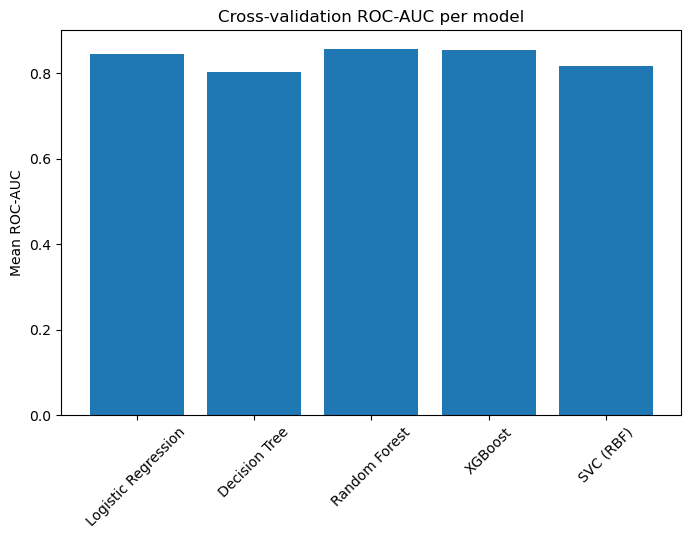

In [564]:
plt.figure(figsize=(8,5))

plt.bar(cv_results_df["Model"], cv_results_df["CV ROC-AUC Mean"])

plt.title("Cross-validation ROC-AUC per model")
plt.ylabel("Mean ROC-AUC")
plt.xticks(rotation=45)

plt.show()

En conjunt, els resultats de cross-validation confirmen que els models basats en arbres i ensemble són els més adequats per a aquest problema de detecció de frau, tant en termes de rendiment com d’estabilitat.

La baixa performance de la regressió logística i del SVC reforça la hipòtesi que el problema presenta relacions no lineals complexes i un cert nivell de desbalanceig de classes, que beneficien clarament models més flexibles com Random Forest i XGBoost.